In [5]:
from math import floor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

# load the data
df = pd.read_csv("Data\\MPAA_model_data.csv")

df['carbon index norm'] = df['carbon index norm'].fillna(df['carbon index norm'].mean())

# List of municipalities IDs
municipalities = df['NM_MUN'].tolist()

# Biodiversity score for each municipality Bio_i
Bio = df.set_index('NM_MUN')['biodiversity_priority_index'].to_dict()

# Extinction risk normalised E_hat_i
E_hat = df.set_index('NM_MUN')['Extinction risk score norm'].to_dict()

# Carbon sequestration potential for each municipality Car_hat_i
Car_hat = df.set_index('NM_MUN')['carbon index norm'].to_dict()

# Land available for planting in each municipality A_i
A = df.set_index('NM_MUN')['eligible_area_ha_mapbiomas'].to_dict()

# Urgency score U_hat_i
U_hat = df.set_index('NM_MUN')['urgency_5yr_index'].to_dict()

# Reversal risk Rev_hat_i
Rev_hat = df.set_index('NM_MUN')['reversal_risk'].to_dict()

# cost per hectare for each municipality c_i
c = df.set_index('NM_MUN')['cost_per_ha'].to_dict()

# max cost per hectare across all municipalities (for cost-effectiveness)
c_max = max(c.values())
c_max

# ========================= Fixed Additional Parameters ======================== 
B = 489850000  # Total budget in dollars
arc_min = 12350000 # Minimum funding for Arc of Deforestation municipalities (based on historical funding levels and adjusted for inflation)
m = 200    # Minimum viable project scale in hectares
K = 560000 # Updated based on new data and assumptions - can implement up to 560,000 hectares per year across all municipalities
N_min = 25       # Minimum number of municipalities to fund (Fairness constraint)
theta = 0.20  # No municipality can receive more than 20% of the total budget B

# weight constraints
alpha_B = 0.5      # Weight for Biodiversity
beta_B = 0.5       # Weight for Extinction Risk


In [2]:
arc_municipalities = [
    "Abaetetuba",
    "Abel Figueiredo",
    "Acará",
    "Ananindeua",
    "Aurora do Pará",
    "Bagre",
    "Baião",
    "Barcarena",
    "Belém",
    "Benevides",
    "Bom Jesus do Tocantins",
    "Brejo Grande do Araguaia",
    "Breu Branco",
    "Bujaru",
    "Cametá",
    "Canaã dos Carajás",
    "Conceição do Araguaia",
    "Concórdia do Pará",
    "Curionópolis",
    "Eldorado do Carajás",
    "Floresta do Araguaia",
    "Goianésia do Pará",
    "Igarapé-Miri",
    "Inhangapi",
    "Irituia",
    "Itupiranga",
    "Jacundá",
    "Limoeiro do Ajuru",
    "Mãe do Rio",
    "Marituba",
    "Mocajuba",
    "Moju",
    "Nova Ipixuna",
    "Oeiras do Pará",
    "Palestina do Pará",
    "Piçarra",
    "Salvaterra",
    "Santa Bárbara do Pará",
    "Santa Izabel do Pará",
    "São Domingos do Araguaia",
    "São Domingos do Capim",
    "São Geraldo do Araguaia",
    "São João do Araguaia",
    "Sapucaia",
    "Tailândia",
    "Tomé-Açu",
    "Tucuruí",
    "Xinguara",
    "Água Azul do Norte",
    "Anajás",
    "Anapu",
    "Bannach",
    "Bonito",
    "Breves",
    "Cachoeira do Arari",
    "Castanhal",
    "Chaves",
    "Colares",
    "Cumaru do Norte",
    "Curralinho",
    "Gurupá",
    "Marabá",
    "Melgaço",
    "Muaná",
    "Novo Repartimento",
    "Ourém",
    "Ourilândia do Norte",
    "Pacajá",
    "Parauapebas",
    "Pau D'Arco",
    "Ponta de Pedras",
    "Portel",
    "Porto de Moz",
    "Redenção",
    "Rio Maria",
    "Santa Cruz do Arari",
    "Santa Luzia do Pará",
    "Santa Maria das Barreiras",
    "Santana do Araguaia",
    "Santo Antônio do Tauá",
    "São Caetano de Odivelas",
    "São Félix do Xingu",
    "São Francisco do Pará",
    "São Miguel do Guamá",
    "São Sebastião da Boa Vista",
    "Senador José Porfírio",
    "Soure",
    "Vigia",
    "Capitão Poço",
    "Dom Eliseu",
    "Garrafão do Norte",
    "Ipixuna do Pará",
    "Nova Esperança do Piriá",
    "Paragominas",
    "Rondon do Pará",
    "Ulianópolis",
    "Viseu"]

In [4]:
def constraint_aware_greedy_heuristic(
    df, B, K, m, N_min, arc_min, arc_municipalities, theta=0.20
):

    h = df.copy()
    h['carbon index norm'] = h['carbon index norm'].fillna(h['carbon index norm'].mean())
    h['in_arc'] = h['NM_MUN'].isin(arc_municipalities)

    max_budget_per_mun = theta * B

    # 1. Setup: feasible land capped  by the physical land and the per-municipality budget limit
    h['A_eff'] = h['eligible_area_ha_mapbiomas'].clip(lower=0) 
    h['A_budget_cap'] = max_budget_per_mun / h['cost_per_ha']
    h['A_eff_cap'] = h[['A_eff', 'A_budget_cap']].min(axis=1)

    h = h[h['A_eff_cap'] >= m].copy()
    h = h.sort_values('urgency_5yr_index', ascending=False).reset_index(drop=True)

    # Initialize tracking variables
    h['Area_ha'] = 0.0
    h['Cost'] = 0.0
    h['selected'] = False

    rem_B = B
    rem_K = K
    arc_spent = 0.0

    def allocate(idx, target_ha):
        """
        Attempts to add hectares to a municipality up to target_ha,
        respecting remaining budget, remaining capacity, and the
        municipality-specific budget cap.
        """
        nonlocal rem_B, rem_K

        c_i = h.at[idx, 'cost_per_ha']
        current_ha = h.at[idx, 'Area_ha']
        current_cost = h.at[idx, 'Cost']

        remaining_mun_budget = max_budget_per_mun - current_cost
        if remaining_mun_budget <= 0:
            return 0.0

        affordable_ha_global = rem_B / c_i
        affordable_ha_mun = remaining_mun_budget / c_i
        remaining_area_cap = h.at[idx, 'A_eff_cap'] - current_ha

        add_ha = min(
            target_ha - current_ha,
            affordable_ha_global,
            affordable_ha_mun,
            rem_K,
            remaining_area_cap
        )

        # Enforce minimum viable scale only on first activation
        if current_ha == 0 and add_ha < m:
            return 0.0

        if add_ha > 0:
            cost = add_ha * c_i
            h.at[idx, 'Area_ha'] += add_ha
            h.at[idx, 'Cost'] += cost
            h.at[idx, 'selected'] = True
            rem_B -= cost
            rem_K -= add_ha
            return cost

        return 0.0

    # ==========================================
    # PHASE 1: ARC OF DEFORESTATION COMPLIANCE
    # ==========================================
    for idx, row in h[h['in_arc']].iterrows():
        if arc_spent >= arc_min:
            break

        still_needed_ha = (arc_min - arc_spent) / row['cost_per_ha']
        target_ha = max(min(still_needed_ha, row['A_eff_cap']), m)
        cost_added = allocate(idx, target_ha)
        arc_spent += cost_added

    # ==========================================
    # PHASE 2: GEOGRAPHIC EQUITY (N_min) COMPLIANCE
    # ==========================================
    funded_count = h['selected'].sum()

    if funded_count < N_min:
        for idx, row in h[~h['selected']].iterrows():
            if funded_count >= N_min:
                break
            cost_added = allocate(idx, m)
            if cost_added > 0:
                funded_count += 1

    # ==========================================
    # PHASE 3: GREEDY FILL
    # ==========================================
    for idx, row in h.iterrows():
        if rem_B <= 0 or rem_K <= 0:
            break

        allocate(idx, row['A_eff_cap'])

    h['Municipality'] = h['NM_MUN']

    final_arc_spend = (
        h.loc[h['in_arc'] & h['selected'], 'Area_ha']
        * h.loc[h['in_arc'] & h['selected'], 'cost_per_ha']
    ).sum()

    return h

In [10]:
h_bench = constraint_aware_greedy_heuristic(
    df, B, K, m, N_min, arc_min, arc_municipalities, theta=0.20
)

# Extract JUST the clean table of funded municipalities
results_table = h_bench[h_bench['selected']][['Municipality', 'Area_ha', 'Cost']].reset_index(drop=True)


results_table = results_table.sort_values('Area_ha', ascending=False).reset_index(drop=True)

# save to CSV
results_table.to_csv("Outputs/Para Allocations/Heuristic_allocation_results.csv", index=False)

In [11]:
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

municipalities_gdf = gpd.read_file("C:\\Users\\alasd\\OneDrive\\Desktop\\1. University\\Third Year\\1. Mathematical Programming in Advanced Analytics\\Group Project\\Code\\Data\\BR_Municipios_2024.shp")


def budget_allocation_para_municipality_graphic(alloc_df, obj_name, all_municipalities):
    allocation = alloc_df.copy()

    allocation = allocation.merge(
        df[['NM_MUN', 'CD_MUN']],
        left_on='Municipality',
        right_on='NM_MUN',
        how='left'
    )

    # list of municipalities in para
    para_municipalities = municipalities_gdf[municipalities_gdf['NM_UF'] == "Pará"]

    para_municipalities['CD_MUN'] = para_municipalities['CD_MUN'].astype(int)

    # merge the geodataframe with allocation datagrame to get the geometry for each municipality
    para_alloc = para_municipalities.merge(
        allocation,
        left_on='CD_MUN',
        right_on='CD_MUN',
        how='left'
    )
    # check how many municipalities have missing allocations (i.e., not selected in the optimal solution)
    print(para_alloc["Cost"].isna().sum(), "municipalities missing allocations")
    print(len(para_alloc), "total municipalities")

    return para_alloc

def plot_budget_allocation_map(para_alloc, obj_name):
    import matplotlib.ticker as mticker

    para_municipalities = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"]
    funded = para_alloc[para_alloc["Cost"].notna() & (para_alloc["Cost"] > 0)].copy()

    if funded.empty:
        print("No funded municipalities found (Cost > 0).")
        return

    vmin = funded["Cost"].min()
    vmax = funded["Cost"].max()

    fig = plt.figure(figsize=(12, 12))
    ax_map = fig.add_axes([0.05, 0.08, 0.85, 0.84])

    para_municipalities.plot(
        ax=ax_map, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )

    funded.plot(
        ax=ax_map,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    sm = plt.cm.ScalarMappable(cmap="YlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.03, pad=0.02)
    cbar.set_label("Reforestation Budget (USD)", fontsize=16)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    cbar.ax.tick_params(labelsize=14)

    ax_map.annotate(
        "N", xy=(0.96, 0.95), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )
    ax_map.annotate(
        "▲", xy=(0.96, 0.92), xycoords="axes fraction",
        ha="center", va="top", fontsize=18
    )

    ax_map.set_title(
        f"Reforestation Budget Allocation Across Pará Municipalities\nObjective: {obj_name}",
        fontsize=18, fontweight="bold", pad=12
    )
    ax_map.set_axis_off()


    # saving the figure to /Figures folder which is a subfolder of the current working directory
    out_dir = Path("Figures/Para Allocation Plots")
    filename = f"Para_Budget_Map_{obj_name.replace(' ', '_')}.png"
    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

c:\Users\alasd\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


119 municipalities missing allocations
144 total municipalities


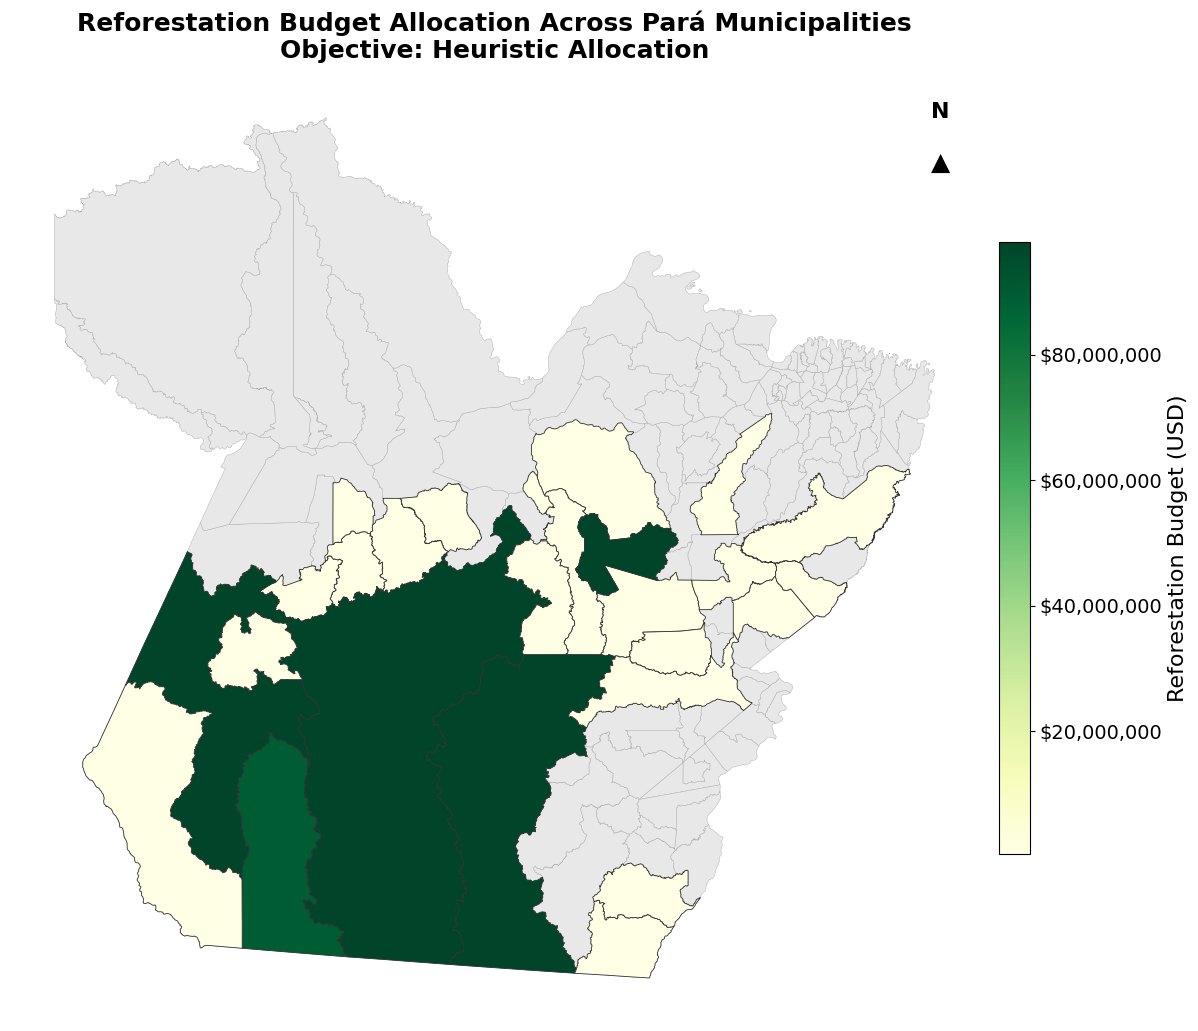

In [12]:
plot_budget_allocation_map(budget_allocation_para_municipality_graphic(results_table, 'Heuristic Allocation', municipalities_gdf), 'Heuristic Allocation')

In [ ]:
from itertools import combinations

# Load distance matrix (same source used in MILP workflow)
dist_df = pd.read_csv("Data\\distance_matrix_named.csv", index_col=0)

# Align labels
dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)

# Selected municipalities from heuristic
selected_muns = set(
    h_bench.loc[h_bench["selected"], "Municipality"].astype(str).tolist()
)

# Build all municipality pairs from your master list
mun_ids = [str(m) for m in municipalities]
mun_pairs = list(combinations(mun_ids, 2))

# Optional threshold for comparability with your MILP setup
D_max = 250.0

spatial_score_heur = 0.0
count_active_pairs = 0
count_missing = 0

for i, j in mun_pairs:
    # Only active when both are selected (heuristic equivalent of z_ij = y_i*y_j)
    if i not in selected_muns or j not in selected_muns:
        continue

    dij = None
    try:
        dij = float(dist_df.at[i, j])
    except Exception:
        try:
            dij = float(dist_df.at[j, i])
        except Exception:
            count_missing += 1
            continue

    # Match MILP threshold behavior; remove this if you want "all distances"
    if dij > 0 and dij <= D_max:
        spatial_score_heur += 1.0 / dij
        count_active_pairs += 1

print("Heuristic spatial score (MILP-comparable):", round(spatial_score_heur, 6))
print("Active selected pairs counted:", count_active_pairs)
print("Missing distance lookups skipped:", count_missing)

allocated_hectares = h_bench['Area_ha'].fillna(0)


# Calculate Objective F1: Biodiversity & Threat
# MILP Formula: sum((alpha_B * Bio[i] + beta_B * E_hat[i]) * x[i])
score_f1_bio = sum((alpha_B * h_bench['biodiversity_priority_index'] + 
                    beta_B * h_bench['Extinction risk score norm']) * allocated_hectares)

# 4. Calculate Objective F2: Carbon Sequestration
# MILP Formula: sum(Car_hat[i] * x[i])
score_f2_car = sum(h_bench['carbon index norm'] * allocated_hectares)

# 5. Calculate Objective F3: Urgency
# MILP Formula: sum(U_hat[i] * x[i])
score_f3_urg = sum(h_bench['urgency_5yr_index'] * allocated_hectares)

# 6. Calculate Objective F4: Reversal Risk
# MILP Formula: sum(Rev_hat[i] * x[i])
score_f4_rev = sum(h_bench['reversal_risk'] * allocated_hectares)

# 7. Calculate Objective F5: Spatial Score
score_f5_spat = spatial_score_heur  # From the spatial score calculation above

# now put these scores into a dictionary for easy comparison
bench_scores = {
    'F1_biodiversity': score_f1_bio,
    'F2_carbon': score_f2_car,
    'F3_urgency': score_f3_urg,
    'F4_reversal': score_f4_rev,
    'F5_spatial': score_f5_spat
}

print("Heuristic Objective Scores:")
for key, value in bench_scores.items():
    print(f"  {key}: {value}")


Heuristic spatial score (MILP-comparable): 0.425717
Active selected pairs counted: 59
Missing distance lookups skipped: 0
Heuristic Objective Scores:
  F1_biodiversity: 106680.13801266512
  F2_carbon: 101686.33295347224
  F3_urgency: 141988.57646703327
  F4_reversal: 216865.49271909508
  F5_spatial: 0.4257172581233039


In [22]:
bench_scores_df = pd.DataFrame([bench_scores])

In [15]:
# plot radars for heuristic and milp solution only
z1_star = 140747.23  # Biodiversity & extinction risk score 
z2_star = 127860.74  # Carbon sequestration score
z3_star = 90556.79  # Urgency score
z4_star = 127082.92  # Reversal risk score
z5_star = 0.1083  # Spatial score (not optimised in MILP, but we can calculate it for the heuristic)

milp_scores = {
    'F1_biodiversity': z1_star,
    'F2_carbon': z2_star,
    'F3_urgency': z3_star,
    'F4_reversal': z4_star,
    'F5_spatial': z5_star
}

# convert to dataframe for plotting
milp_scores_df = pd.DataFrame.from_dict(milp_scores, orient='index', columns=['MILP_Score']).T
milp_scores_df


,F1_biodiversity,F2_carbon,F3_urgency,F4_reversal,F5_spatial
MILP_Score,140747.23,127860.74,90556.79,127082.92,0.1083


In [20]:
# importing pay_off matrix for radar plot
payoff_df = pd.read_csv("Outputs\\payoff_table.csv", index_col=0)
payoff_df

,Bio_and_extinction_val,Car_val,Urg_val,Rev_val,Spatial_val
Biodiversity and Extinction,145998.502805,124695.095262,59183.776586,87859.077485,0.280907
Carbon,40017.678279,193410.001968,23882.438370,115229.042176,1.657612
Urgency,106612.747244,101693.530573,141990.933009,216855.272249,0.439335
Reversal Risk,1036.651394,5313.825487,38.212297,0.000000,3.457952
Spatial Penalty,18294.757367,104509.359591,22874.281628,96802.080686,0.086386


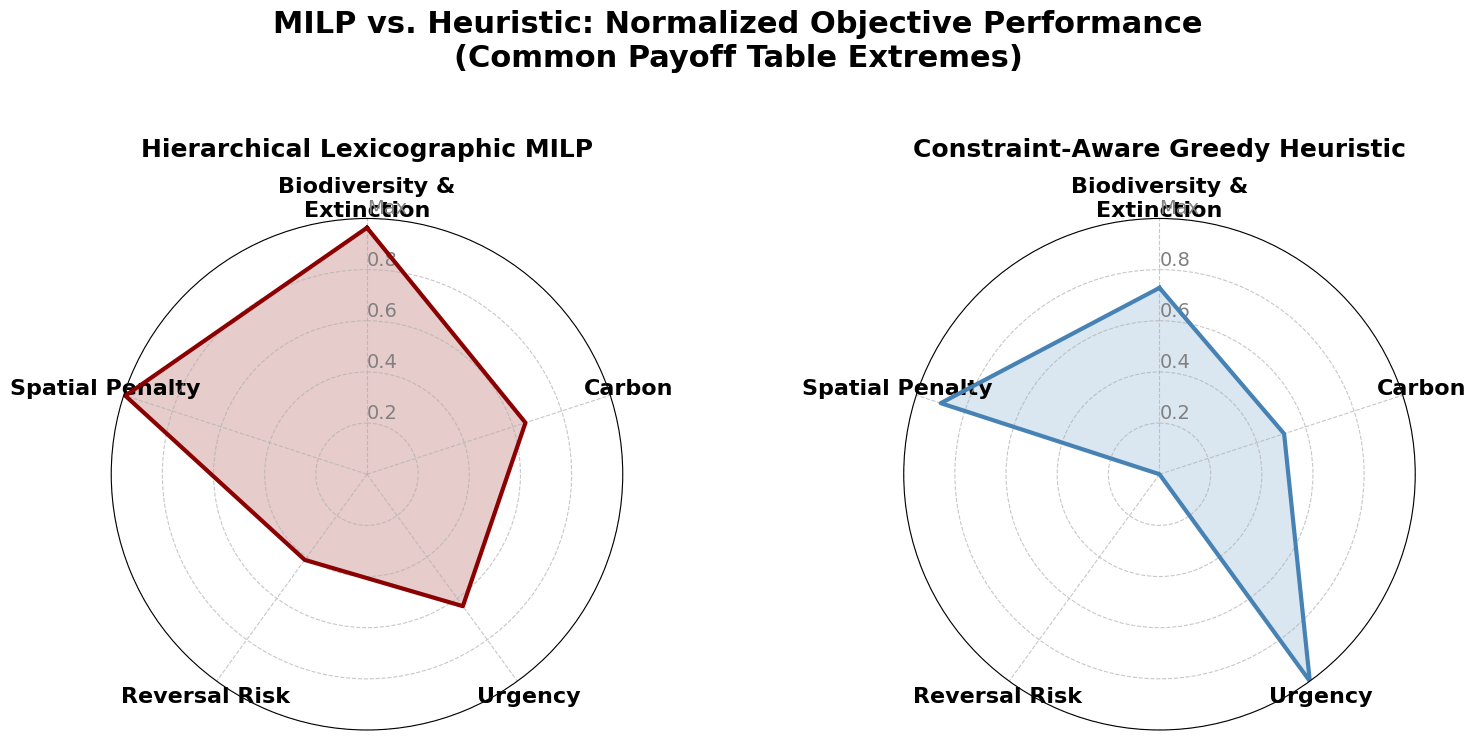

In [35]:
from math import pi
import numpy as np

# Get utopia and nadir from payoff_df for normalization (common extremes for both solutions)
bio_nadir = payoff_df['Bio_and_extinction_val'].min()
bio_utopia = payoff_df['Bio_and_extinction_val'].max()

car_nadir = payoff_df['Car_val'].min()
car_utopia = payoff_df['Car_val'].max()

urg_nadir = payoff_df['Urg_val'].min()
urg_utopia = payoff_df['Urg_val'].max()

# Minimize objectives (inverted)
rev_nadir = payoff_df['Rev_val'].max()
rev_utopia = payoff_df['Rev_val'].min()

spatial_nadir = payoff_df['Spatial_val'].max()
spatial_utopia = payoff_df['Spatial_val'].min()

# Normalize MILP scores
milp_norm_values = {}
milp_norm_values['Bio'] = (milp_scores_df['F1_biodiversity'].values[0] - bio_nadir) / (bio_utopia - bio_nadir)
milp_norm_values['Carbon'] = (milp_scores_df['F2_carbon'].values[0] - car_nadir) / (car_utopia - car_nadir)
milp_norm_values['Urgency'] = (milp_scores_df['F3_urgency'].values[0] - urg_nadir) / (urg_utopia - urg_nadir)
milp_norm_values['Reversal'] = (rev_nadir - milp_scores_df['F4_reversal'].values[0]) / (rev_nadir - rev_utopia)
milp_norm_values['Spatial'] = (spatial_nadir - milp_scores_df['F5_spatial'].values[0]) / (spatial_nadir - spatial_utopia)
milp_norm_values = {k: max(0, min(1, v)) for k, v in milp_norm_values.items()}

# Normalize Benchmark (heuristic) scores
bench_norm_values = {}
bench_norm_values['Bio'] = (bench_scores_df['F1_biodiversity'].values[0] - bio_nadir) / (bio_utopia - bio_nadir)
bench_norm_values['Carbon'] = (bench_scores_df['F2_carbon'].values[0] - car_nadir) / (car_utopia - car_nadir)
bench_norm_values['Urgency'] = (bench_scores_df['F3_urgency'].values[0] - urg_nadir) / (urg_utopia - urg_nadir)
bench_norm_values['Reversal'] = (rev_nadir - bench_scores_df['F4_reversal'].values[0]) / (rev_nadir - rev_utopia)
bench_norm_values['Spatial'] = (spatial_nadir - bench_scores_df['F5_spatial'].values[0]) / (spatial_nadir - spatial_utopia)
bench_norm_values = {k: max(0, min(1, v)) for k, v in bench_norm_values.items()}

# Setup radar chart parameters
categories = ['Biodiversity &\nExtinction', 'Carbon', 'Urgency', 'Reversal Risk', 'Spatial Penalty']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Create side-by-side radar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

# ─── LEFT: MILP Solution ───
ax1.set_theta_offset(pi / 2)
ax1.set_theta_direction(-1)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, size=16, fontweight='bold')
ax1.set_rlabel_position(0)
ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "Max"], color="grey", size=14)
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.7)

milp_values = [milp_norm_values['Bio'], milp_norm_values['Carbon'], 
               milp_norm_values['Urgency'], milp_norm_values['Reversal'], milp_norm_values['Spatial']]
milp_values += milp_values[:1]
ax1.plot(angles, milp_values, color='darkred', linewidth=3, linestyle='solid')
ax1.fill(angles, milp_values, color='darkred', alpha=0.2)
ax1.set_title("Hierarchical Lexicographic MILP", size=18, fontweight='bold', pad=15)

# ─── RIGHT: Heuristic Solution ───
ax2.set_theta_offset(pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=16, fontweight='bold')
ax2.set_rlabel_position(0)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "Max"], color="grey", size=14)
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle='--', alpha=0.7)

bench_values = [bench_norm_values['Bio'], bench_norm_values['Carbon'], 
                bench_norm_values['Urgency'], bench_norm_values['Reversal'], bench_norm_values['Spatial']]
bench_values += bench_values[:1]
ax2.plot(angles, bench_values, color='steelblue', linewidth=3, linestyle='solid')
ax2.fill(angles, bench_values, color='steelblue', alpha=0.2)
ax2.set_title("Constraint-Aware Greedy Heuristic", size=18, fontweight='bold', pad=15)

fig.suptitle("MILP vs. Heuristic: Normalized Objective Performance\n(Common Payoff Table Extremes)", 
             size=22, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig("Figures/Radar Plots/Radar_MILP_vs_Heuristic_Side_by_Side.png", dpi=300, bbox_inches='tight')
plt.show()